# Feature Level Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

# Root path setup
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / "dataset/processed"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

d:\Sarthak\Sem VI\Project mini\network-traffic-anomaly-analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data and model

In [3]:
# Loading data
fp_windows = pd.read_csv(PROCESSED_DIR / 'fp_windows.csv', index_col=0)
fn_windows = pd.read_csv(PROCESSED_DIR / 'fn_windows.csv', index_col=0)

df_full = pd.read_csv(PROCESSED_DIR / 'full_windowed.csv')
normal_windows = pd.read_csv(PROCESSED_DIR / 'normal_windowed.csv')

eval_results = pd.read_csv(PROCESSED_DIR / 'eval_results.csv', index_col=0)

feature_cols = [col for col in df_full.columns
                if col not in ['window_id', 'window_attack']]

pure_normal = df_full[df_full['window_attack'] == 0]
pure_attack = df_full[df_full['window_attack'] == 1]

pure_attack = pure_attack[pure_attack.index > 1000]
eval_set = pd.concat([pure_normal, pure_attack])

# Load saved model and scaler
iso = joblib.load(MODEL_DIR / 'isolation_forest.pkl')
scaler = joblib.load(MODEL_DIR / 'scaler.pkl')

# Scaling from saved scaler
X_eval_scaled = scaler.transform(eval_set[feature_cols])
X_fp_scaled = scaler.transform(fp_windows[feature_cols])

## 2. SHAP (SHapley Additive exPlanations)
### Feature level Analysis

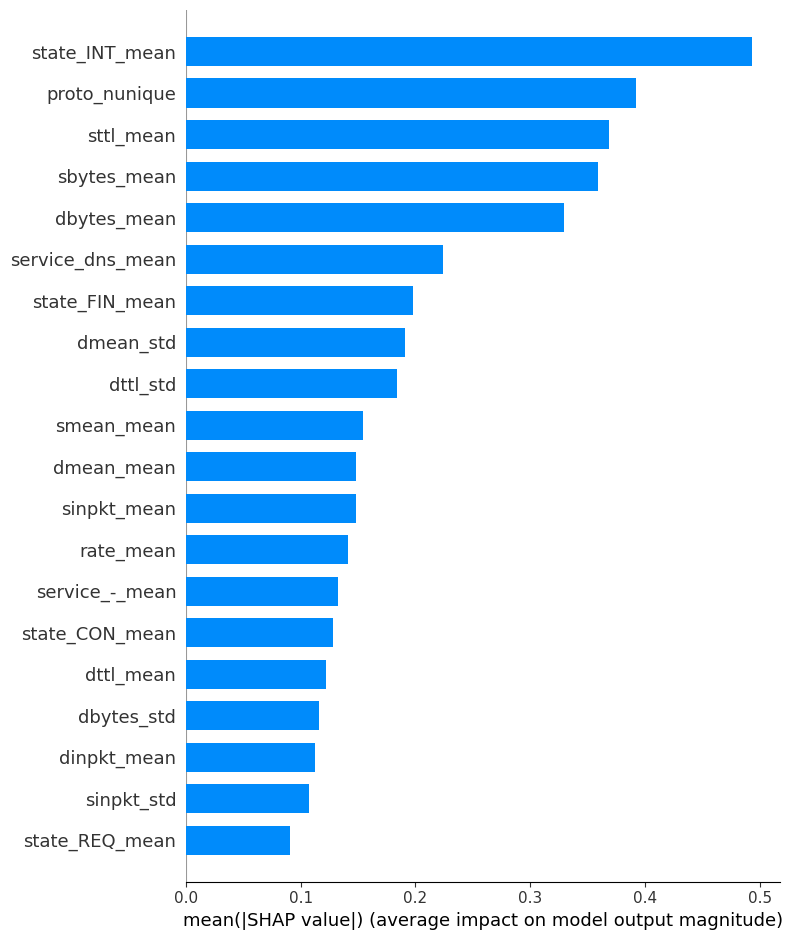

In [4]:
# SHAP explainer for Isolation Forest
explainer = shap.TreeExplainer(iso)
shap_values_eval = explainer.shap_values(X_eval_scaled)
shap_values_fp = explainer.shap_values(X_fp_scaled)

# Global feature importance
shap.summary_plot(shap_values_eval, eval_set[feature_cols], plot_type='bar', title='Feature Importance')

In [5]:
# Compare top features
top_features = ['state_INT_mean', 'proto_nunique', 'sttl_mean', 
                'sbytes_mean', 'dbytes_mean', 'service_dns_mean']

comparison = pd.DataFrame({
    'true_normal_mean': pure_normal[top_features].mean(),
    'fp_mean': fp_windows[top_features].mean(),
    'true_attack_mean': pure_attack[top_features].mean()
})

print(comparison)

                  true_normal_mean     fp_mean  true_attack_mean
state_INT_mean            0.044697    0.223947          0.747558
proto_nunique             2.407098    2.631579          6.310757
sttl_mean                62.334175  180.867895        227.908243
sbytes_mean               7.196469    6.607423          5.560432
dbytes_mean               7.426189    4.054634          1.683050
service_dns_mean          0.156409    0.004474          0.525261


In [ ]:
# Compare FP feature means vs normal means
print("\nFP windows vs Normal windows — feature comparison:\n")

fp_vs_normal = pd.DataFrame({
    'normal_mean': pure_normal[feature_cols].mean(),
    'fp_mean': fp_windows[feature_cols].mean()
})

fp_vs_normal['difference'] = abs(fp_vs_normal['fp_mean'] - fp_vs_normal['normal_mean'])

print(fp_vs_normal.sort_values('difference', ascending=False).head(10))


FP windows vs Normal windows — feature comparison:

             normal_mean     fp_mean  difference
sttl_mean      62.334175  180.867895  118.533719
dttl_mean      53.212630  143.789211   90.576580
dttl_std       28.666543   81.852844   53.186301
sttl_std       28.719502   57.111767   28.392265
dbytes_mean     7.426189    4.054634    3.371555
sinpkt_mean     1.796831    3.967462    2.170631
dmean_mean      4.859813    2.772214    2.087599
rate_mean       6.490992    4.734835    1.756157
dinpkt_mean     1.572304    2.575674    1.003370
rate_std        2.024855    2.909825    0.884971


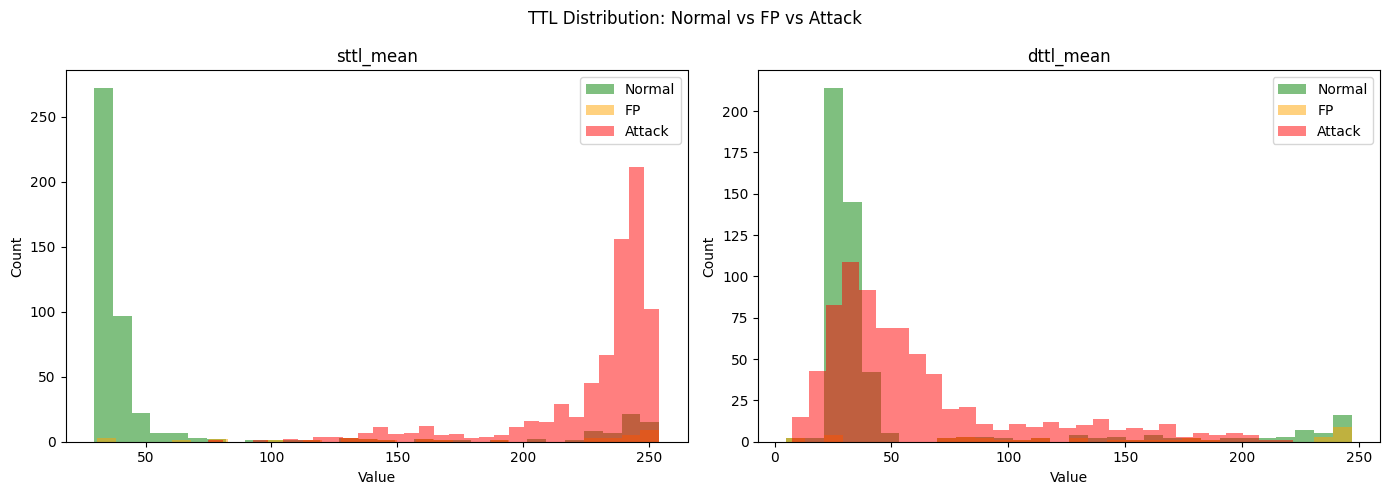

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['sttl_mean', 'dttl_mean']):
    ax.hist(pure_normal[col], bins=30, alpha=0.5, label='Normal', color='green')
    ax.hist(fp_windows[col], bins=30, alpha=0.5, label='FP', color='orange')
    ax.hist(pure_attack[col], bins=30, alpha=0.5, label='Attack', color='red')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('TTL Distribution: Normal vs FP vs Attack')
plt.tight_layout()
plt.show()

In [8]:
# How many FP windows fall outside normal TTL range?
for col in ['sttl_mean', 'dttl_mean']:
    mean = pure_normal[col].mean()
    std = pure_normal[col].std()
    # TTL Range
    low, high = mean - 2*std, mean + 2*std
    
    fp_outside = ((fp_windows[col] < low) | (fp_windows[col] > high)).sum()
    attack_outside = ((pure_attack[col] < low) | (pure_attack[col] > high)).sum()
    normal_outside = ((pure_normal[col] < low) | (pure_normal[col] > high)).sum()
    
    print(f"\n{col} normal range: [{low:.2f}, {high:.2f}]")
    print(f"FPs outside range:     {fp_outside}/{len(fp_windows)} ({fp_outside/len(fp_windows):.1%})")
    print(f"Attacks outside range: {attack_outside}/{len(pure_attack)} ({attack_outside/len(pure_attack):.1%})")
    print(f"Normals outside range: {normal_outside}/{len(pure_normal)} ({normal_outside/len(pure_normal):.1%})")


sttl_mean normal range: [-70.60, 195.27]
FPs outside range:     20/38 (52.6%)
Attacks outside range: 668/753 (88.7%)
Normals outside range: 54/479 (11.3%)

dttl_mean normal range: [-62.25, 168.68]
FPs outside range:     15/38 (39.5%)
Attacks outside range: 32/753 (4.2%)
Normals outside range: 41/479 (8.6%)


In [9]:
def compute_deviation_score(row, normal_df, features):
    score = 0
    for col in features:
        mean = normal_df[col].mean()
        std = normal_df[col].std() + 1e-10
        score += abs((row[col] - mean) / std)  # z-score contribution   
    return score / len(features)

top_features = ['sttl_mean', 'dttl_mean', 'dttl_std', 
                'sttl_std', 'dbytes_mean', 'sinpkt_mean']

# Calculate deviation of top features.
# how far each window deviates from normal behavior
eval_set['deviation_score'] = eval_set.apply(
    lambda row: compute_deviation_score(row, pure_normal, top_features), axis=1
)

fp_windows['deviation_score'] = fp_windows.apply(
    lambda row: compute_deviation_score(row, pure_normal, top_features), axis=1
)

pure_normal['deviation_score'] = pure_normal.apply(
    lambda row: compute_deviation_score(row, pure_normal, top_features), axis=1
)

pure_attack['deviation_score'] = pure_attack.apply(
    lambda row: compute_deviation_score(row, pure_normal, top_features), axis=1
)

print("FP deviation scores:")
print(fp_windows['deviation_score'].describe())

print("\nNormal deviation scores:")
print(pure_normal['deviation_score'].describe())

print("\nAttack deviation scores:")
print(pure_attack['deviation_score'].describe())

FP deviation scores:
count    38.000000
mean      1.850969
std       0.397286
min       0.837049
25%       1.708224
50%       1.874507
75%       2.143494
max       2.524566
Name: deviation_score, dtype: float64

Normal deviation scores:
count    479.000000
mean       0.714233
std        0.542988
min        0.200155
25%        0.387033
50%        0.552729
75%        0.657757
max        2.524566
Name: deviation_score, dtype: float64

Attack deviation scores:
count    753.000000
mean       1.829801
std        0.172044
min        1.545733
25%        1.733838
50%        1.768938
75%        1.834919
max        2.575337
Name: deviation_score, dtype: float64
